##**Problema  1: Análisis de ecuaciones diferenciales 1D**
Analice graficamente las siguientes ecuaciones diferenciales de primer orden. Encuentre  los puntos fijos, analice su estabilidad analiticamente y realice los gráficos de trayectoria en el espacio de fases.

1.   $\dot{x} = a x $
2.  $\dot{x} = x - x^3$
3. $\dot{x} = 1 -2 \cos{x}$



##**Problema 2: Análisis de ecuaciones diferenciales lineales 2D**
 Considere los siguientes sistemas dinámicos:

1.   $\dot{x} = 4x-y$, $\dot{y} = 2x + y$
2.    $\dot{x} = 5x + 2y$, $\dot{y} = 17x - 5y$
3.   $\dot{x} = y$, $\dot{y} = -x$

Para cada sistema:

(i) Escriba al sistema en forma matricial $\mathbf{\dot{x}}=\mathbf{A}\mathbf{x}$. Busque el polinomio característico.

(ii) Encuentre la solución general del sistema

(iii) Clasifique el punto fijo (estable, inestable o saddle)

(iv) Realice el diagrama de fases en papel y compare numericamente


##**Problema 3: Análisis de ecuaciones diferenciales no lineales 2D***
Considere los siguientes sistemas dinámicos:

1.   $\dot{x} = x -x^3$, $\dot{y} = -y$
2.   $\dot{x} = x- y$, $\dot{y} = x^2-4$
3.   $\dot{x} = x(2-x-y)$, $\dot{y} = x-y$

La ecuación del **péndulo** $\ddot{\theta} = -g/l \, \sin{\theta}$ puede ser escrita como una ecuación de primer orden en dos variables, si tomamos $\omega = \dot{\theta}$

4. $\dot{\theta} = \omega$, $\dot{\omega} = -g/l \, \sin{\theta}$

Para cada sistema:

(i) Dibuje las nulclideas, busque puntos fijos y analice estabilidad

(ii) Haga un diagrama del espacio de fases  en papel y compare numéricamente



100%|██████████| 90000/90000 [00:05<00:00, 17112.55it/s]


((-5.0, 5.0), (-5.0, 5.0))

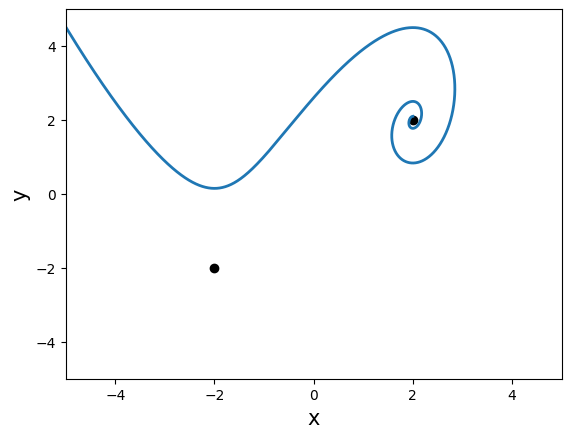

In [ ]:
#Integracion de trayectoria en el espacio de fases
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def esquema(X, F, t, dt):
    """
    Calcula X(t+dt) a partir de X(t) y el

    Parámetros:
      F : Campo vector en función de (x,t)
      t : Tiempo donde se conoce t
      dt: Paso temporal
    """
    #RK4
    k1 = dt * F(t, X)
    k2 = dt * F(t + 0.5 * dt, X + 0.5 * k1)
    k3 = dt * F(t + 0.5 * dt, X + 0.5 * k2)
    k4 = dt * F(t + dt, X + k3)
    return X + (k1 + 2*k2 + 2*k3 + k4) / 6


def trayectoria(X0, F, N, dt):
    """
    Calcula numéricamente una trayectoria en el espacio de fases cómo
    un arreglo, usando el esquema definido previamente

    Parámetros:
      X0: Condición inicial cómo arreglo de dimensión d
      F : Campo vector en funciń de (x,t)
      N : Número de pasos temporales
      dt: Paso temporal
    """
    d = X0.shape[0]            # Dimensión del problema
    ts = np.arange(0, N+1)*dt  # Tiempos donde calcularé la solución
    Xs = np.zeros((N+1, d))    # Solución aproximada
    Xs[0] = X0                 # Impongo la condición inicial a t=0
    for j in tqdm(range(N)):
        # Aplico esquema anterior sobre Xs[j] para obtener Xs[j+1]
        Xs[j+1] = esquema(Xs[j], F, ts[j], dt)
    return ts, Xs


#Ej de sistema dinámico
def ecuacion(t, X):
  dtx = X[0] - X[1]
  dty = X[0]**2 - 4
  return np.array([dtx, dty])

#Parametros para integracion de una trayectoria
dt = 1e-4
N = 90000
tf = dt*N

X0 = np.array([2, 2.1])
t, X = trayectoria(X0, ecuacion, N, dt)

#Diagrama de fases 2D
PF = np.array([[2, 2], [-2, -2]])

plt.plot(X[:,0], X[:,1], linewidth = 2)
plt.scatter(PF[:, 0], PF[:, 1], color = 'k')
plt.xlabel('x', fontsize = 15), plt.ylabel('y', fontsize = 15)
plt.xlim(-5, 5), plt.ylim(-5, 5)

(Text(0.5, 0, 'x'), Text(0, 0.5, 'x'))

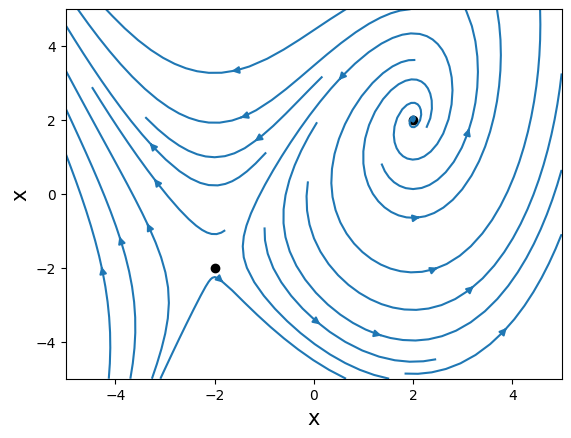

In [ ]:
# Asi podemos ver rapidamente el campo vectorial

# Definimos una grilla de puntos
XX, YY = np.meshgrid(np.arange(-5, 5, .01), np.arange(-5, 5, .01))
# Campo en un instante t
campo_vectorial = ecuacion(t, [XX, YY])

#Grafico
plt.streamplot(XX, YY, campo_vectorial[0], campo_vectorial[1], density=.8, minlength=.5)
plt.scatter(PF[:, 0], PF[:, 1], color = 'k')
plt.xlabel('x', fontsize = 15), plt.ylabel('x', fontsize = 15)

In [ ]:
#Asi podemos ver el espacio de fases. Recordemos que si el campo depende del t, las lineas de campo NO coinciden con las trayectorias
# Importamos la libreria control.
!pip install control

(Text(0.5, 9.444444444444466, 'x'), Text(9.444444444444452, 0.5, 'y'))

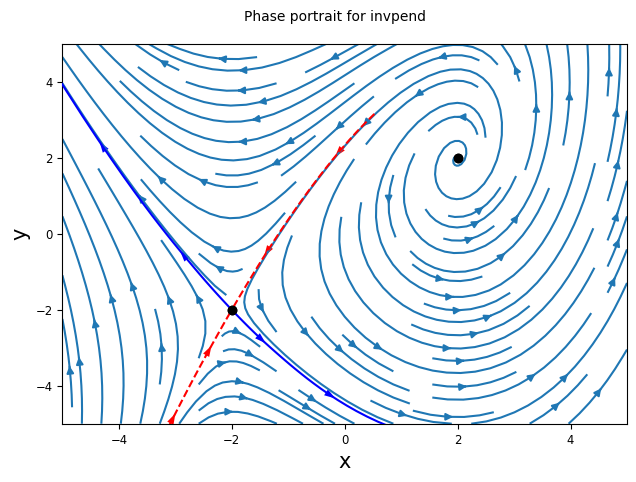

In [ ]:
import control as ct

#resolvemos
invpend = ct.nlsys(lambda t, X, u, params : ecuacion(t, X) , states=2, inputs=1, name='invpend') #u es un forzado en el tiempo y params parametros de la funcion

#grafico
ct.phase_plane_plot(invpend, [-5, 5, -5, 5])
#graficamos puntos fijos y agregamos labels
plt.scatter(PF[:, 0], PF[:, 1], color = 'k')
plt.xlabel('x', fontsize = 15), plt.ylabel('y', fontsize = 15)

##**Problema 4: Estudio de bifurcaciones en 1D**
Para los siguientes ejercicios, busque los puntos fijos al variar $r$, construya el diagrama de bifurcaciones ($x^*$ vs $r$ ) y grafique el diagrama de fases en cada región del parámetro donde el sistema cambie cualitativamente.

**Bifurcacion saddle-node**.
1. $\dot{x} = 1 + rx + x^2$
2. $\dot{x} = r + x- \ln{1+x}$

**Bifurcacion transcritica**.

2. $\dot{x} = r x + x^2$

4. $\dot{x} = rx -\ln{(1+x)}$

**Bifurcacion pithfork**.

3. $\dot{x} = rx + 4x^3$

6. $\dot{x} = rx -\sinh{x}$

##**Problema 5: Bifurcaciones en 2D***
Para estos campos vectoriales pueden aparecer las mismas bifurcaciones que en sistemas unidimensionales, así como bifurcaciones de nuevos tipos.

Dado los  siguientes sistemas dinamicos:

1. $\dot{x} = \mu - x^2$, $\dot{y} = -y$

2. $\dot{x} = x (1 - \frac{x}{y})$, $\dot{y} = y(1- y)-\frac{\mu}{x}$

(i) Construya el diagrama de bifurcaciones ($x^*$ vs $\mu$) y clasifique la bifurcación (saddle, transcritica o pitchfork)

(ii) Grafique el diagrama de fases en cada región del parámetro donde el sistema cambie cualitativamente

##**Problema 6: Bifurcación de Hopf***
**Bifurcación Hopf**. Dado los  siguientes sistemas dinamicos:

1. $\dot{x} = \mu x-y- x(x^2 + y^2)$, $\dot{y} = x + \mu y - y(x^2 + y^2)$
2. $\dot{x} = y + \mu x$, $\dot{y} = x + \mu y - x^2 y$

 (i) Reescriba el sistema en coordenadas polares.

(ii) Muestre que el origen tiene una bifurcación de Hopf en $\mu = 0$.

(iii) Mediante simulaciones vea si es subcrítica o supercrítica y grafique $x(t)$ para los distintos casos


##**Problema 7: Esto ya lo vimos en F1***

Una particula de masa $m$ se encuentra engarzada en un anillo circular de radio $R$. El anillo gira con velocidad angular: $\mathbf{\Omega} = \Omega \hat{z}$. Hay gravedad: $\mathbf{g} = - g \hat{z}$.

(i) Escriba las ecuaciones de Newton para la particula y deduzca: $\ddot{\theta} =  \Omega^2\sin{θ}(\cos{\theta}-\frac{g}{\Omega^ 2 R})$

(b) Defina $\dot{\theta} = \omega$ y reescriba la ecuacion como un sistemas de dos ecuaciones a primer orden  en $\theta$ y $\omega$

(ii) Busque puntos fijos del sistema y relice el diagrama de bifurcaciones correspondiente.

(iii) Realice el diagrama de fases correspondiente para cada parte en cual el sistema cambie cualitativamente

##**Problema 8: Oscilador de Van der Pol***

La ecuación de Van der Pol tiene una larga historia  tanto en las ciencias físicas como en las biológicas. En este último contexto, Richard FitzHugh y Jinichi Nagumo desarrollaron una extensión en dos variables que permite describir la dinámica de los potenciales de acción en neuronas.

Originalmente, esta ecuación fue introducida por el ingeniero y físico holandés Balthasar van der Pol, quien observó la aparición de oscilaciones estables en circuitos eléctricos con tubos de vacío. A estas oscilaciones las denominó oscilaciones de relajación, y hoy se entienden como un caso particular de ciclos límite.

Matemáticamente, la ecuación describe un oscilador armónico con un término no conservativo, que puede inyectar o disipar energía dependiendo del valor de la variable dinámica $x$

$$\ddot{x} + \alpha (x^2 - 1 ) \dot{x} + x = 0$$

i) Reescriba la ecuación como una ecuación de primer orden para dos variables $u$ y $v$.

ii) En el caso con $\alpha = 0$ encuentre la expresión de la energía (puede hacerlo a partir de la física o como una integral primera de la ecuación). A partir de la energía obtenida anteriormente obtenga la ecuación de balance (evolución temporal de la energía) en el caso general $\left( \frac{dE}{dt} = g(x,\dot{x},t) \right)$.

(iii) Encuentre el PF y nulclinas.  

(vi) Implemente  Rungge  Kutta de orden cuarto,  considere los valores de  $\alpha = 0.5 , 1.5$ y $3$ ocho treyectorias en este, integradas hasta $t_f = 5$. Agregue  nulclinas e identifique posibles ciclos límites.  

(v) Para los mismos $\alpha$ del inciso anterior, grafique una la evolución temporal $x(t)$ de una trayectoria. Note que al variar $\alpha$ se modifica el período de la oscilación, observándose regiones con dinámica más rápida y otras más lenta. ¿Cómo se reflejan dichas escalas temporales en el espacio de fases?


##**Problema 9: Atractor de Lorentz***
En 1963, [Lorenz](https://https://journals.ametsoc.org/view/journals/atsc/20/2/1520-0469_1963_020_0130_dnf_2_0_co_2.xml) derivo el siguiente sistema tridimensional de ecuaciones, mediante una simplificación drástica del problema de los rollos de convección en la atmósfera:


$$ \dot{x} = \sigma (y-x) \\
\dot{y} = \rho x - y - xz \\
\dot{z} = xy - \beta z$$

donde $x$, $y$ y $z$ son funciones que dependen del tiempo. Las mismas ecuaciones también aparecen en modelos de láseres y dínamos, y describen de manera exacta el funcionamiento de un tipo específica de rueda de agua.

Lorenz descubrió que este sistema determinístico, sencillo a priori, puede presentar una dinámica extremadamente errática. Dados ciertos parámetros, el sistema oscila de forma irregular, de manera tal que nunca repite exactamente la misma oscilación, pero manteniéndose siempre en una región acotada del espacio de fases. Al graficar esas trayectorias en 3D, descubrió que las mismas se acomodan en un set complejo, conocido hoy como atractor de Lorenz.


(i) Busque los puntos fijos del sistema, analice su estabilidad y realice diagrama de bifurcaciones $x*$ vs $\rho$.

(ii) Fije numericamente los parametros  $\beta=8/3$ y $\sigma=10$ e integre  el sistema usando $dt=10^{-4}$.
Para cada uno de los valores $\rho$ listados a continuacion, grafique $x(t)$ vs $t$,  $z(t)$ vs $x(t)$ y la trayectoria en el espacio  de fases $(x, y, z)$ considerando distintas condiciones iniciales (para cada caso hay una sugerencia para que sepa por donde empezar).

 1. $\rho$ = 0.5 (one fix point).

    *Sugerencia:* tiempo de 20 y condicion inicial $(x^´_0,y^´_0,z^´_0)$=$(1, 1,0.5)$

 2. $\rho$ = 5  (two stable mainfolds).

    *Sugerencia:* tiempo de 20 y condiciones iniciales $(x^´_0,y^´_0,z^´_0)$=$(1, 0.5,0.5)$, $(-1, -0.5,0.5)$

 3. $\rho$ = 20 (transient chaos).

    *Sugerencia:* tiempo de 35 y condiciones iniciales $(x^´_0,y^´_0,z^´_0)$=$(0.5, -0.5, 0)$, $(-0.5, 0.5, 0)$, $(-1, .0.5, 10)$


 4. $\rho$ = 28 (strange attractor, chaos).

    *Sugerencia:* tiempo de 40 y condiciones iniciales $(x^´_0,y^´_0,z^´_0)$= $(-0.5, 0.5, 0)$



Discuta si las trayectorias convergen a un punto fijo, si existen orbitas periodicas y, en caso afirmativo, si dichas orbitas son estables o si el comportamiento del sistema es caotico


(iii) Usando $\rho=30$ compare la evolución temporal de $y$ para las condiciones iniciales  $(x_0,y_0,z_0)=(0,0.5,0.5)$ y $(x^´_0,y^´_0,z^´_0)=(0,0.5,0.50001)$. ¿Qué observa?

(iv) Para el caso anterior, grafique la distancia entre los puntos en función del tiempo. Hágalo en escala log-log, interprete el tipo de comportamiento que tiene.

**Ref:**
[Eusebius J Doedel et al 2015 Nonlinearity 28 R113](https://iopscience.iop.org/article/10.1088/0951-7715/28/11/R113/pdf?casa_token=424PwMEitGkAAAAA%3ABK2T3hBqO69Ku1y645tdNcx3eEqCkLE1QsBReDU3UkzqwWtw2lVdzHdkT-nA3GbeNSEFYs_pKnX5DahI_1-9)

/tmp/ipython-input-3012532546.py:33: RuntimeWarning: invalid value encountered in sqrt
  PF = np.array([[0, 0, 0], [np.sqrt(1-rho), np.sqrt(1-rho), (1-rho)/beta], [np.sqrt(1-rho), np.sqrt(1-rho), (1-rho)/beta]])
100%|██████████| 499999/499999 [00:18<00:00, 27611.38it/s]


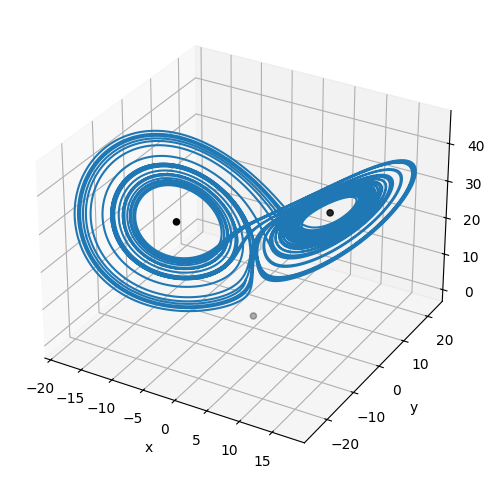

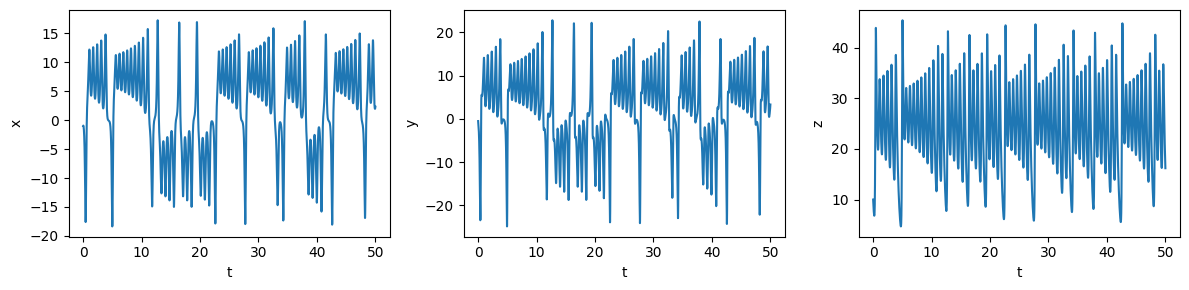

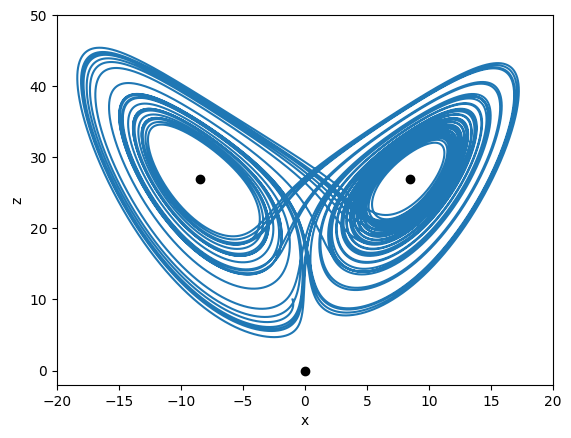

In [ ]:
from numpy.random import beta
#Sistema dinamico
def lorentz(t, X):
  #completar
  dtx =
  dty =
  dtz =
  return np.array([dtx, dty, dtz])

#parametros de la simulacion
dt = 1e-4
N = int(20/dt)
tf = dt*N
t = np.linspace(0, tf, N)

beta =  #completar
sigma =  #completar
rho =  #completar

X0 = #completar
PF = np.array([[]])

#Integración
X = trayectoria(X0, lorentz, N, dt)

#Una trayectoria en el espacio de fases 3D
fig = plt.figure(figsize=(8, 6))
axs = fig.add_subplot(111, projection='3d')

axs.plot3D(X[:, 0], X[:, 1], X[:, 2])
axs.scatter(PF[:, 0], PF[:, 1], PF[:, 2], color = 'k')
axs.set_xlabel('x')
axs.set_ylabel('y')
axs.set_zlabel('z')
plt.show()

#Una trayectoria en el tiempo
fig, axs = plt.subplots(1, 3, figsize = (12, 3))
ax = axs[0]
ax.plot(t, X[:, 0])
ax.set_xlabel('t'), ax.set_ylabel('x')
ax = axs[1]
ax.plot(t, X[:, 1])
ax.set_xlabel('t'), ax.set_ylabel('y')
ax = axs[2]
ax.plot(t, X[:, 2])
ax.set_xlabel('t'), ax.set_ylabel('z')
fig.tight_layout()
plt.show()

#Una trayectoria en el plano xz
fig, ax = plt.subplots(1, 1)
ax.plot(X[:, 0], X[:, 2])
ax.scatter(PF[:, 0], PF[:, 2], color = 'k')
ax.set_xlabel('x'), ax.set_ylabel('z')
ax.set_xlim(-20, 20), ax.set_ylim(-2, 50)
plt.show()


##**Ej10: Ginzburg Landau con campo real***

La ecuación de Ginzburg–Landau es comúnmente utilizada para describir el comportamiento de distintos sistemas cerca de una transición de fase (por ejemplo, la convección de Rayleigh-Bénard). La ecuación describe la evolución temporal de un campo mediante un término lineal, asociado a la estabilidad del estado trivial $u=0$ a primer orden, una correción no lineal  y un término difusivo que introduce el acoplamiento espacial del campo. Este último término penaliza gradientes espaciales fuertes y tiende a suavizar el campo

$$ \frac{\partial u}{\partial t} = \mu u - \beta u³ + D \nabla ^2 u$$

Aquí $u = u(x, t)$ es un campo unidimensional real y $\mu$, $\beta$, $D$ son parámetros positivos.

(i) Considere el caso sin difusión: $D = 0$. Vea analíticamente la/las bifurcaciones del campo de velocidades.

(ii) Para el sistema del inciso (i), integre numericamente para los distintos valores de $\mu/\beta$. Grafique $u(x, t)$ para distintas condiciones iniciales.

(iii) Considere $D\neq 0$ y vea si

\begin{equation}
    E(t) = \int_0^L \frac{1}{2} \left( \frac{\partial u}{\partial t} \right)^2 + V(u) \, dx, \qquad V(u) = \frac{(\mu u - \beta u^3)^2}{2}
\end{equation}
es una magnitud conservada.

(iv) Agregue el término difusivo, integre numéricamente los casos analizados en (ii) y compare ambas dinámicas. *Puede probar con $D =$ 0, 1, 5*.

#**Problema 11: Kuramoto Shivashinsky**

La dinámica de una fina película de líquido a lo largo de un plano inclinado puede ser descripta por la ecuación de [Kuramoto-Sivashinsky](https://en.wikipedia.org/wiki/Kuramoto%E2%80%93Sivashinsky_equation) adimensionalizada. Sus términos constan de  balance entre inestabilidad, difusión y no linealidad,

$$ \frac{\partial u}{\partial t} =  - \frac{\partial^2 u}{\partial x^2} - \frac{\partial^4 u}{\partial x^4}  - u\frac{\partial u}{\partial x}$$

donde $u(x, t)$ es la velocidad del flujo, $t$ es el tiempo y $x$ es la coordenada paralela al plano inclinado, en una aproximación unidimensional. En particular, vamos a estudiar este modelo en un dominio periódico $[0, L]$.

##**11.1: Propiedades Generales**

(i) Pruebe que $M(t) = \int_0^L u~\text{d}x$ es una magnitud conservada.

(ii) Pruebe que esta ecuación es invariante ante transformaciones de Galileo $u\to u+U$, $x\to x + Ut$.

(iii) Pruebe que es invariante ante reflexiones $u\to-u$, $x\to-x$.

(iv)  Realice el cambio de variables $x→ x\, L/2\pi$ y  $u→ u\,   2\pi/L$, donde $0\leq x\leq 2\pi$,  y muestre que Kuramoto Shivashinsky  queda:
$$ \frac{\partial u}{\partial t} =  - \frac{\partial^2 u}{\partial x^2} - k^2 \frac{\partial^4 u}{\partial x^4}  - u\frac{\partial u}{\partial x}$$
donde $k = 2\pi/L$ y  $t\rightarrow t \, (2\pi/ L)^2$.

*Aquí se puede ver que cambiar el tamaño  del recinto es equivalente cambiar el peso  del término difusivo $-\partial^4 u/\partial x^4$.*

##**11.2  Expansión de Galerkin con simetría**
Ahora pasaremos a estudiar exactamente una expansión de Galerkin de bajo orden.
Las propiedades del problema anterior nos permiten realizar múltiples simplificaciones.
Juntando las propiedades 1(i) y 1(ii), podemos imponer $M(t) \equiv 0$ durante la evolución, por lo que el modo 0 será automáticamente nulo. Más aún, si nos restringimos a condiciones iniciales antisimétricas tal que $u(x, 0) = -u(-x, 0)$, la propiedad 1(iii) nos asegura que $u(x, t) = -u(-x, t)~~\forall~t$.

Por lo tanto, podemos restringir nuestra expansión de Fourier a una expansión en senos (equivalentemente, sabemos que los coeficientes de lo cosenos serán automáticamente nulos) de la forma de la forma que puedo tomar base ortonogonal de senos $\{\sin{(mx)}, m \in \mathbb{N}\}$, tal que:

$$ u(x, t) = \sum_{m = 1}^{∞}a_m(t) \sin\left(m x\right) \approx a_1(t)  \sin(x) + a_2(t)  \sin(2x) + ...$$

  (i) Muestre que el sistema de ecuaciones para los modos es:

 $$ \dot{a}_{\ell} (t) = (1 - k^2 \ell ^2) \ell ^2 a_{\ell}(t) - \frac{1}{2} \sum_{m = 1}^{∞} m\, a_m(t) (\textrm{sg}(\ell - m)a_{|\ell - m|}(t) + a_{\ell + m}(t) )$$
    *Ayuda:* use la propiedad de la suma del seno y ortogonalidad  de los modos: $\sin{(n\pm m)} = \sin{n}\cos{m} \pm \cos{n} \sin{m}$,  $\int_0^{2\pi} \sin(nx) \sin(mx) =\pi \delta_{m, n}$.


Veamos la estabilidad de la solución homogénea  ($u = 0$) utilizando la formulación en términos de las amplitudes de Fourier. Si el campo de velocidad es nulo, entonces $a_{\ell} = 0$ para $\forall \ell$. Alrededor de este punto las amplitudes $a_{\ell}$ serán chicas.

  (ii) Linearice el sistema de ecuaciones para las amplitudes obtenido en (i) alrededor de $a_{\ell} = 0$ para $\forall \ell$. Vea qué condición debe cumplir $L$ para que cada modo $\ell$ sea estable. Al agrandar el parámetro $L$ ¿Cuál es el primer modo en desestabilizarse? Note que agandar $L$ ( disminur $k$) es disminuir la contribución del término difusivo  en Kuramoto Sivashinsky.

  (iii) Trunque a dos modos y escriba  el sistema de EDOs para $a_1(t)$ y $a_2(t)$.

  (iv) Calcule los puntos fijos $(A_1^{(j)}, A_2^{(j)})$ y determine su estabilidad.

  (v) Grafique todos los $A_1^{(j)}$ cómo funciones de  $L$, marcando claramente cuando son estables, puntos silla o inestables, ¿que tipo de bifurcaciones observa?

  (vi) (opcional) Trunque a cuatro modos, busque puntos fijos y analice estabilidad.

## **11.3: Simulaciones numéricas**
Pasaremos ahora a implementar un método pseudoespectral para resolver el modelo de Kuramoto-Sivashinsky. En el fondo, sigue siendo una expansión de Galerkin pero a un orden mucho mayor, tal que un enfoque analítico no es tractable. Además, hacemos uso de los métodos de [transformada rápida de Fourier](https://en.wikipedia.org/wiki/Fast_Fourier_transform) (FFT, por sus siglas en inglés) para trabajar de forma más eficiente con los términos no lineales.


Por cuestiones de estabilidad numérica, es necesario que el paso temporal $\Delta t$ sea lo suficientemente chico (sino nuestras soluciones divergirán y el programa dará _overflow_), según dicta la condición de [Courant-Friedrichs-Lewy](https://en.wikipedia.org/wiki/Courant%E2%80%93Friedrichs%E2%80%93Lewy_condition) para este problema puntual:

$$ \frac{\Delta t}{\Delta x^4} \lesssim C $$

donde $C$ es una constante habitualmente entre $0.1$ y $1$, dependiendo del problema y método de integración temporal utilizado (pruebe distintos valores hasta que funcione y luego reescale siguiendo esta ley).


 (i) Integre el sistema de ecuaciones para dos amplitudes utilizando el método de Runge Kutta hasta un tiempo $t_f = 4$, con condiciones iniciales
 $$(a_1(0), a_2(0))= (1, 0)$$
 para los valores del parámetro $1/k = L/2\pi =$ 0.8 , 1.2 y 1.94. Grafique $a_1$ vs $a_2$.  


 (ii) Integre la ecuación de Kuramoto–Sivashinsky mediante un método pseudoespectral, usando las condiciones iniciales
    $$u(0, x) = -\sin(x)$$
  
y los mismos valores del parámetro $1/k = L/2\pi =$ 0.8, 1.2 y 1.94. Extraiga $a_1$ y $a_2$  y compare con  los resultados del inciso (i).


 (iii) Repita el inciso (ii), pero integrando ahora el sistema de amplitudes truncado a cuatro modos y utilizando $1/k= L/2\pi$= 2.5. *Sugerencia:puede graficar tres amplitudes en un espacio tridimensional*

 (iv) Utilizando el método pseudoespectral, integre la ecuación de Kuramoto Sivashinsky para distintos valores del parámetro $L$. Pruebe al menos con los siguientes valores
  1.  $1/k = L/2\pi = 4.22$
  2.  $1/k = L/2\pi = 5 $
  3.  $1/k = L/2\pi = 5.12 $
  4.  $1/k = L/2\pi = 6.075  $
  5.  $1/k = L/2\pi = 8  $

 Para cada caso, elija un conjunto de  dos o tres amplitudes de Fourier para graficar la trayectoria en este espacio. Describa qué ve en cada caso (convergencia, oscilaciones, caos, combinación de todo).

*Nota: al aumentar L hay que aumentar el numero de grilla. Pruebe usando $N_x$: 64, 128, 256, 512.*

  (v) (opcional) Diviertase, vea el campo $u$  si resuelve Kuramoto Sivasinsky para $L\geq 10$. Pruebe al menos tres valores de $L$.

In [ ]:
def sine_transform(u, axis=-1):
    u_rfft = np.fft.rfft(u, axis=axis)
    u_rfft *= -2/u.shape[axis]
    ks = np.fft.rfftfreq(u.shape[axis])
    slicer = [slice(None)] * u_rfft.ndim
    slicer[axis] = slice(1, None)
    return ks[1:], u_rfft.imag[tuple(slicer)]

# Ojo, falta definir el Nx y dx
kx = 2*np.pi*np.fft.fftfreq(Nx, dx)
kmax = np.abs(kx).max()*2/3
idxs = (np.abs(kx) > kmax)

def dealias(f_fft):
    f_fft[idxs] = 0.0
    return f_fft
